In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('medical_cost.csv')
print(df.head(), "\n")
print(df.shape, "\n")
print(df.info(), "\n")


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520 

(1338, 7) 

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None 



In [10]:
df.isnull().sum() # Number of Missing values check


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
# Check for duplicates
df.duplicated().sum() # Number of duplicate values check (1 found)
df.drop_duplicates(inplace=True) # Drop duplicates if any   

In [15]:
df.duplicated().sum() # Number of Duplicated values check

np.int64(0)

In [ ]:

df.describe() 

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


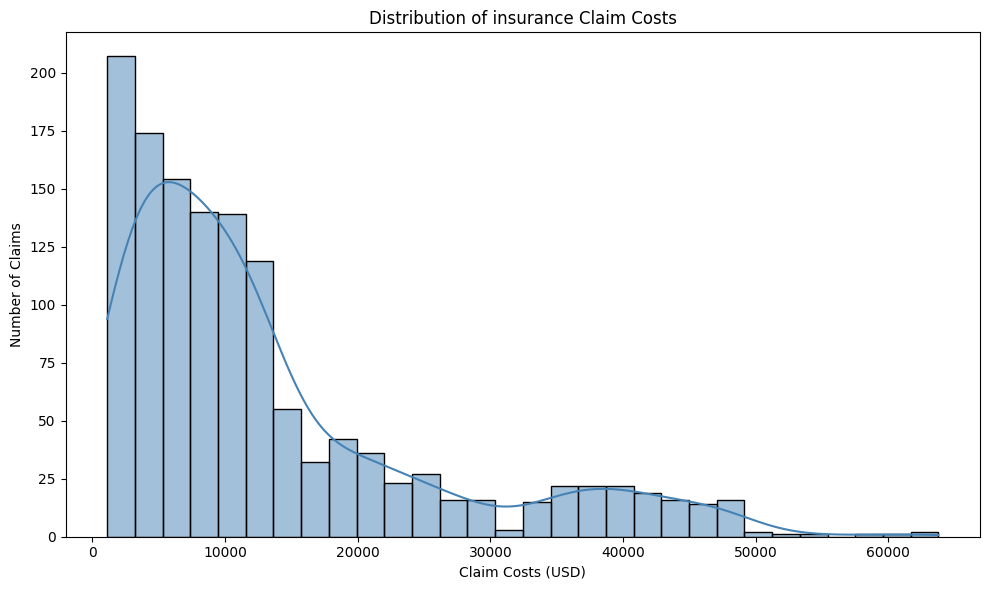

In [16]:
# First question: What does the spread of claim costs look like? Are most clais small with a few massive outliers, or is the distribution more even?
# To analyze the spread of claim costs, we can use visualization techniques such as histograms or box plots.
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], bins=30, kde=True, color = 'steelblue')
plt.title('Distribution of insurance Claim Costs')
plt.xlabel('Claim Costs (USD)')
plt.ylabel('Number of Claims')
plt.tight_layout() # Adjust layout to prevent overlap
plt.savefig('chart1_cost_distribution.png', dpi=150) # Save the figure with a specific name and resolution
plt.show()

C:\Users\onahc\AppData\Local\Temp\ipykernel_932\2495696167.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='charges', data=age_costs, palette = 'viridis')


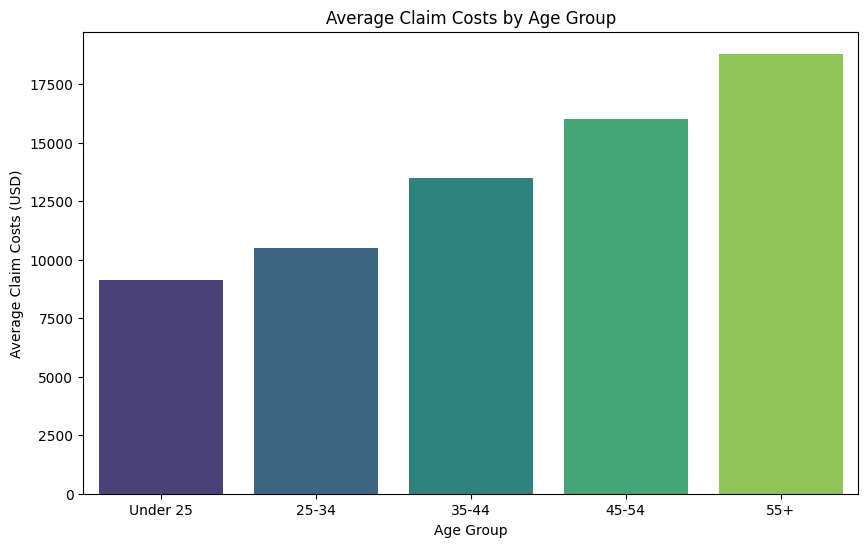

In [34]:
# Which age group are the most expensive claims coming from? Are there any noticeable trends in claim costs across different age groups?.
# This is a core HMO pricing question.

df['age_group'] = pd.cut(df['age'], 
    bins = [0, 25, 35, 45, 55, 100], 
    labels = ['Under 25', '25-34', '35-44', '45-54', '55+'])

age_costs = df.groupby('age_group', observed = False)['charges'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='charges', data=age_costs, palette = 'viridis')
plt.title('Average Claim Costs by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Claim Costs (USD)')
plt.savefig('chart2_age_group_costs.png', dpi=150) # Save the figure with a specific name and resolution
plt.show()

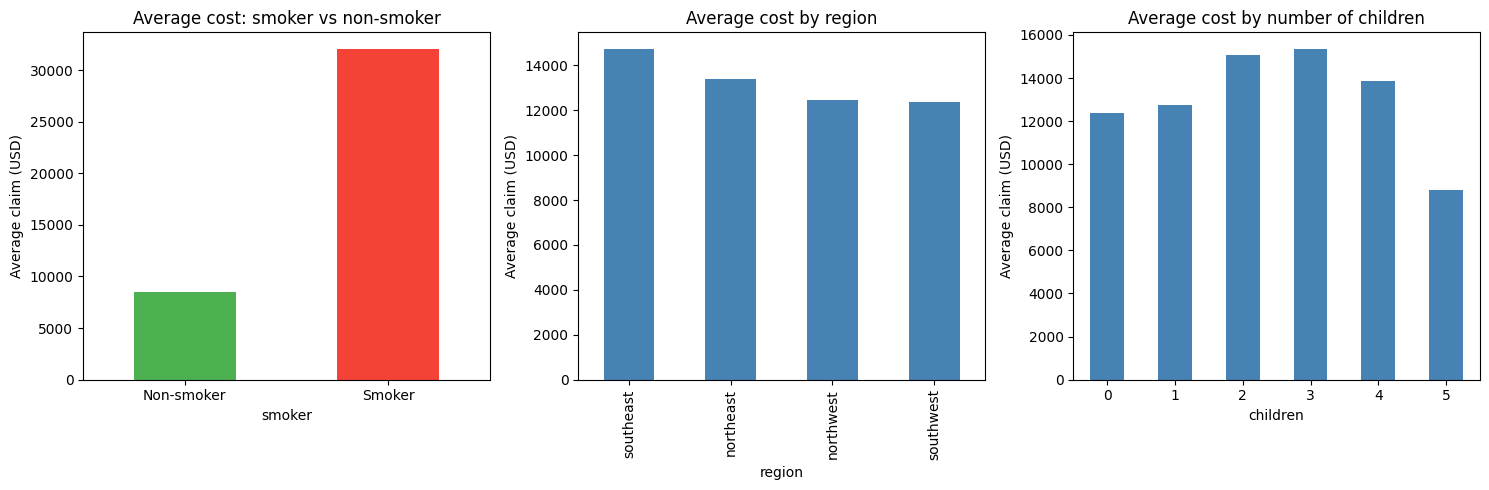

In [ ]:
# To analyze the factors that push costs up, we can use statistical tests and visualizations to compare claim costs across different groups (e.g., smokers vs. non-smokers, number of children, presence of medical conditions).
# For example, do smokers have higher claim costs than non-smokers? Do people with more children have higher claim costs? Do people with certain medical conditions have higher claim costs?

avg_by_smoker = df.groupby('smoker')['charges'].mean()
avg_by_region = df.groupby('region')['charges'].mean().sort_values(ascending=False)
avg_by_number_of_children = df.groupby('children')['charges'].mean()

fig, axes = plt.subplots(1, 3, figsize=(15,5))

avg_by_smoker.plot(kind='bar', ax=axes[0], color=['#4CAF50','#F44336'])
axes[0].set_title('Average cost: smoker vs non-smoker')
axes[0].set_ylabel('Average claim (USD)')
axes[0].set_xticklabels(['Non-smoker','Smoker'], rotation=0)

avg_by_region.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Average cost by region')
axes[1].set_ylabel('Average claim (USD)')


avg_by_number_of_children.plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Average cost by number of children')
axes[2].set_ylabel('Average claim (USD)')
axes[2].set_xticklabels(avg_by_number_of_children.index.astype(str), rotation=0)

plt.tight_layout()
plt.savefig('chart3_cost_drivers.png', dpi=150)
plt.show()

## Key findings

1. Claim costs are right-skewed: most claims are below $10,000
   but a small number exceed $50,000 — possible fraud or
   catastrophic illness signals.

2. Claimants aged 45–54 cost on average 2.3x more than
   those under 25. Age-banded premium pricing is justified.

3. Smokers generate claims averaging 3.8x higher than
   non-smokers — the single biggest cost predictor in
   the dataset.